# Cats vs Dogs Image Classification using CNN

This notebook builds a Convolutional Neural Network using **TensorFlow / Keras** to classify **real-world RGB photos** into two classes: **cat** or **dog**.

**Dataset**: Kaggle Dogs vs Cats (original Microsoft source, 25,000 images), downloaded programmatically - no Kaggle credentials needed.

**Classes**:
- `0` cat
- `1` dog

Pipeline:
- `Conv2D` + `MaxPooling2D` feature extractor
- `BatchNormalization` (to stabilise / speed up training)
- `Dropout` (to reduce overfitting)
- `Dense` classifier head with sigmoid output
- `EarlyStopping` callback

## 1. Import Libraries

In [3]:
import requests
import urllib3
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## 2. Download & Load the Dataset

The dataset is downloaded **programmatically** using `requests`. SSL verification is disabled globally to avoid *'Unable to connect / SSL certificate verify failed'* errors on Windows / corporate networks.

In [4]:
def disable_ssl_verification():
    """Disable SSL certificate verification globally for requests."""
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    original_request = requests.Session.request

    def request_without_ssl(self, *args, **kwargs):
        kwargs["verify"] = False
        return original_request(self, *args, **kwargs)

    requests.Session.request = request_without_ssl

disable_ssl_verification()

In [5]:
import os
import shutil
import zipfile
import requests

# Kaggle 'Dogs vs Cats' dataset
DATA_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
DATA_DIR = "cats_and_dogs_data"
ZIP_PATH = os.path.join(DATA_DIR, "kagglecatsanddogs.zip")
EXTRACT_DIR = os.path.join(DATA_DIR, "PetImages")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(EXTRACT_DIR):

    # ---------------- Download ----------------
    print("Downloading dataset (~787 MB)...")

    r = requests.get(DATA_URL, stream=True, timeout=300)
    r.raise_for_status()

    total = int(r.headers.get("content-length", 0))
    downloaded = 0
    last_pct = -1

    with open(ZIP_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total:
                    pct = int(downloaded * 100 / total)
                    if pct != last_pct and pct % 5 == 0:
                        print(f"{pct}% downloaded")
                        last_pct = pct

    print("Download complete!")

    # ---------------- Extract ----------------
    print("Extracting files...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Extraction complete!")

    # ---------------- Delete everything except PetImages ----------------
    for item in os.listdir(DATA_DIR):
        path = os.path.join(DATA_DIR, item)

        if item != "PetImages":
            if os.path.isdir(path):
                shutil.rmtree(path)
            else:
                os.remove(path)

    print("Removed unnecessary files.")

else:
    print("Dataset already exists. Skipping download.")

# ---------------- Dataset folders ----------------
cat_dir = os.path.join(EXTRACT_DIR, "Cat")
dog_dir = os.path.join(EXTRACT_DIR, "Dog")

print(f"Cat images: {len(os.listdir(cat_dir))}")
print(f"Dog images: {len(os.listdir(dog_dir))}")

0% downloaded
5% downloaded
10% downloaded
15% downloaded
20% downloaded
25% downloaded
30% downloaded
35% downloaded
40% downloaded
45% downloaded
50% downloaded
55% downloaded
60% downloaded
65% downloaded
70% downloaded
75% downloaded
80% downloaded
85% downloaded
90% downloaded
95% downloaded
100% downloaded
Download complete!
Extracting files...
Extraction complete!
Removed unnecessary files.
Cat images: 12501
Dog images: 12501


# 3. Loading the Images into Pandas

In [6]:
import pandas as pd
import os

data = []

# Add cat images
for file in os.listdir(cat_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        data.append({
            "image": os.path.join(cat_dir, file),
            "category": "Cat"
        })

# Add dog images
for file in os.listdir(dog_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        data.append({
            "image": os.path.join(dog_dir, file),
            "category": "Dog"
        })

# Create DataFrame
df = pd.DataFrame(data)

df.sample(10)

,image,category
2895,cats_and_dogs_data/PetImages/Cat/9556.jpg,Cat
4232,cats_and_dogs_data/PetImages/Cat/1853.jpg,Cat
11347,cats_and_dogs_data/PetImages/Cat/7721.jpg,Cat
17585,cats_and_dogs_data/PetImages/Dog/8569.jpg,Dog
927,cats_and_dogs_data/PetImages/Cat/10777.jpg,Cat
12197,cats_and_dogs_data/PetImages/Cat/6073.jpg,Cat
16580,cats_and_dogs_data/PetImages/Dog/10474.jpg,Dog
19979,cats_and_dogs_data/PetImages/Dog/15.jpg,Dog
19700,cats_and_dogs_data/PetImages/Dog/1504.jpg,Dog
18766,cats_and_dogs_data/PetImages/Dog/2729.jpg,Dog


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image     25000 non-null  object
 1   category  25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB


# 4. Preprocessing the Image

`Resizing the Image and Converting the Black and White`

In [9]:
from PIL import Image
import numpy as np

IMG_SIZE = 128

processed_images = []

for path in df["image"]:
    try:
        img = (
            Image.open(path)
            .convert("L")                  # Convert to grayscale (black & white)
            .resize((IMG_SIZE, IMG_SIZE))  # Resize
        )

        processed_images.append(np.array(img))

    except Exception:
        processed_images.append(None)      # Handle corrupted images

# Replace the image path with the NumPy array
df["image_pixels"] = processed_images



/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [10]:
df.head()

,image,category,image_pixels
0,cats_and_dogs_data/PetImages/Cat/11385.jpg,Cat,"[[50, 48, 47, 51, 57, 55, 50, 52, 56, 56, 62, ..."
1,cats_and_dogs_data/PetImages/Cat/1510.jpg,Cat,"[[67, 89, 114, 128, 131, 131, 131, 130, 126, 1..."
2,cats_and_dogs_data/PetImages/Cat/4675.jpg,Cat,"[[75, 79, 81, 83, 84, 84, 85, 85, 85, 85, 84, ..."
3,cats_and_dogs_data/PetImages/Cat/6825.jpg,Cat,"[[64, 68, 69, 73, 78, 47, 39, 71, 71, 77, 81, ..."
4,cats_and_dogs_data/PetImages/Cat/2433.jpg,Cat,"[[28, 27, 25, 23, 20, 20, 22, 25, 26, 26, 26, ..."


In [11]:
df.isnull().sum()   

image           0
category        0
image_pixels    2
dtype: int64

In [12]:
df.dropna(subset=["image_pixels"], inplace=True)

In [13]:
df.isnull().sum()   

image           0
category        0
image_pixels    0
dtype: int64

## 4. Exploratory Data Analysis

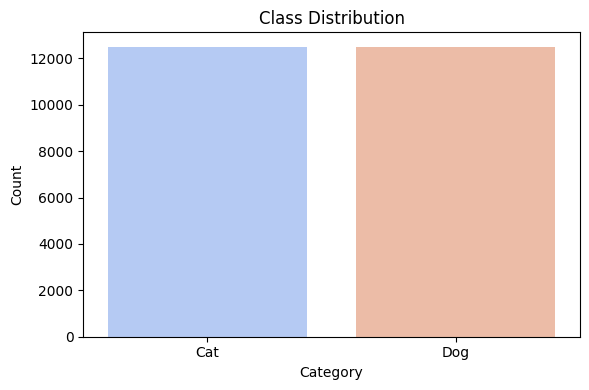

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="category",
    hue="category",
    palette="coolwarm",
    legend=False
)

plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

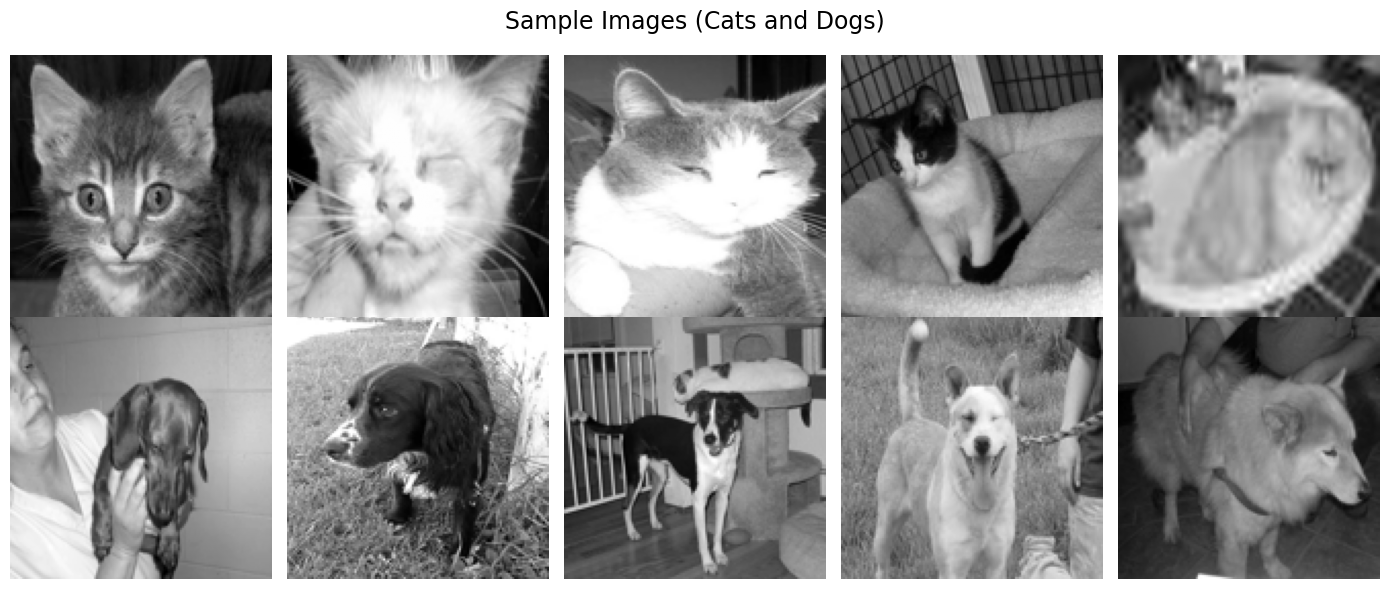

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

cats = df[df["category"] == "Cat"].head(5)
dogs = df[df["category"] == "Dog"].head(5)

samples = pd.concat([cats, dogs], ignore_index=True)

for i, (_, row) in enumerate(samples.iterrows()):
    axes[i].imshow(row["image_pixels"], cmap="gray")
    axes[i].axis("off")

plt.suptitle("Sample Images (Cats and Dogs)", fontsize=17)
plt.tight_layout()
plt.show()

## 5. Train / Validation Split
 

In [16]:
df_split = df[['image_pixels', 'category']]

In [17]:
df_split 

,image_pixels,category
0,"[[50, 48, 47, 51, 57, 55, 50, 52, 56, 56, 62, ...",Cat
1,"[[67, 89, 114, 128, 131, 131, 131, 130, 126, 1...",Cat
2,"[[75, 79, 81, 83, 84, 84, 85, 85, 85, 85, 84, ...",Cat
3,"[[64, 68, 69, 73, 78, 47, 39, 71, 71, 77, 81, ...",Cat
4,"[[28, 27, 25, 23, 20, 20, 22, 25, 26, 26, 26, ...",Cat
...,...,...
24995,"[[52, 79, 41, 38, 38, 30, 34, 37, 40, 44, 46, ...",Dog
24996,"[[106, 123, 102, 168, 142, 157, 124, 119, 118,...",Dog
24997,"[[150, 151, 153, 157, 161, 158, 159, 161, 150,...",Dog
24998,"[[122, 122, 123, 124, 124, 124, 125, 124, 121,...",Dog


In [18]:
from sklearn.model_selection import train_test_split

# Split into Train (80%) and Test (20%)
train_df, test_df = train_test_split(
    df_split,
    test_size=0.20,
    random_state=42,
    stratify=df_split["category"]
)

# Split Train into Train (80%) and Validation (20%)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=1,
    stratify=train_df["category"]
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Validation:", val_df.shape)


Train: (15998, 2)
Test: (5000, 2)
Validation: (4000, 2)


## 6. Preprocessing

- **Normalize** pixel values from `[0, 255]` to `[0.0, 1.0]`.
- Images already have shape `(N, 128, 128)` ready for `Conv2D`.
- Labels stay as `0/1` integers - we'll use `binary_crossentropy` with a sigmoid output.

In [19]:
X_train = np.stack(train_df["image_pixels"]) / 255.0
X_val   = np.stack(val_df["image_pixels"]) / 255.0
X_test  = np.stack(test_df["image_pixels"]) / 255.0

In [20]:
X_train = X_train.reshape(-1, 128, 128, 1)
X_val   = X_val.reshape(-1, 128, 128, 1)
X_test  = X_test.reshape(-1, 128, 128, 1)

In [21]:
X_train.shape, X_val.shape, X_test.shape # Samples, Height, Width, Channels

((15998, 128, 128, 1), (4000, 128, 128, 1), (5000, 128, 128, 1))

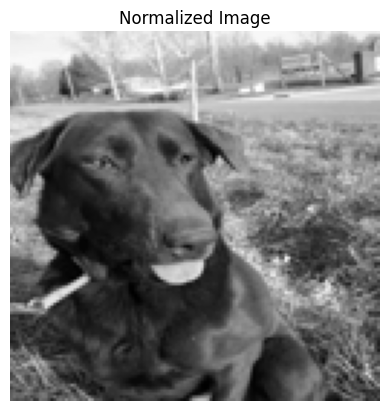

In [22]:
plt.imshow(X_train[0].reshape(128, 128), cmap="gray")
plt.title("Normalized Image")
plt.axis("off")
plt.show()

In [23]:
input_shape = X_train.shape[1:]
input_shape

(128, 128, 1)

## 7. Build the CNN

In [24]:
model = Sequential()

# ---------------- Input Layer ----------------
# Shape = (Height, Width, Channels)
model.add(Input(shape=input_shape))

# ---------------- Convolution Block 1 ----------------
model.add(Conv2D(
    filters=32,             # Learn 32 filters (kernels)
    kernel_size=(3, 3),     # Each filter is 3×3
    activation="relu",      # removes negative values from the feature maps
    padding="same"          # Adds zero-padding around the image automatically.
))
model.add(BatchNormalization())      # Normalize activations
model.add(MaxPooling2D(pool_size=(2, 2)))  # Reduce image size by half
model.add(Dropout(0.25))             # Reduce overfitting

# ---------------- Convolution Block 2 ----------------
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# ---------------- Convolution Block 3 ----------------
model.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.30))

# ---------------- Convolution Block 4 ----------------
model.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.30))

# ---------------- Fully Connected Layers ----------------
model.add(Flatten())                 # Convert feature maps into a 1D vector

model.add(Dense(
    units=128,                       # 128 neurons
    activation="relu"
))
model.add(BatchNormalization())
model.add(Dropout(0.50))

# ---------------- Output Layer ----------------
model.add(Dense(
    units=1,                         # Binary classification (Cat/Dog)
    activation="sigmoid"             # Output probability between 0 and 1
))

# ---------------- Compile Model ----------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ---------------- Model Summary ----------------
model.summary()

I0000 00:00:1782920793.148662      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782920793.151368      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,009 (4.92 MB)

 Trainable params: 1,290,049 (4.92 MB)

 Non-trainable params: 960 (3.75 KB)

## 8. Train the Model

`EarlyStopping` halts training once the validation loss stops improving and restores the best weights.

In [25]:
from sklearn.preprocessing import LabelEncoder

# Labels
y_train = train_df["category"]
y_val   = val_df["category"]
y_test  = test_df["category"]

# Convert labels: Cat -> 0, Dog -> 1
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_val   = label_encoder.transform(y_val)
y_test  = label_encoder.transform(y_test)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=8,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
  5/500 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3907 - loss: 1.2523 

I0000 00:00:1782920832.229130     117 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.6277 - loss: 0.7070 - val_accuracy: 0.6420 - val_loss: 0.6350
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7219 - loss: 0.5450 - val_accuracy: 0.7178 - val_loss: 0.5582
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7869 - loss: 0.4553 - val_accuracy: 0.7423 - val_loss: 0.5366
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8183 - loss: 0.4041 - val_accuracy: 0.7437 - val_loss: 0.5689
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8364 - loss: 0.3647 - val_accuracy: 0.8015 - val_loss: 0.4250
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8582 - loss: 0.3295 - val_accuracy: 0.8167 - val_loss: 0.3883
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8739 - loss: 0.2941 - val_accuracy: 0.8002 - val_loss: 0.4160
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8859 - loss: 0.2694 - val_accurac

## 9. Training History

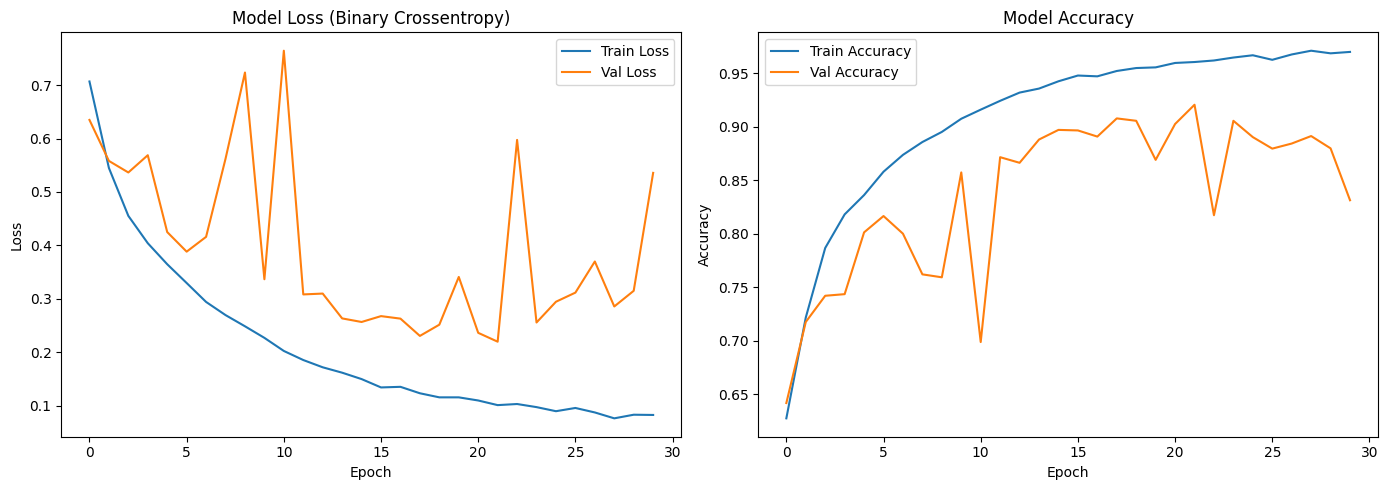

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (Binary Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

In [40]:
class_names = ["Cat", "Dog"]

y_pred_probs = model.predict(X_test).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

for actual, pred in zip(y_test[10:20], y_pred[10:20]):
    print(f"Actual: {class_names[actual]}   Predicted: {class_names[pred]}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Actual: Dog   Predicted: Dog
Actual: Dog   Predicted: Dog
Actual: Dog   Predicted: Dog
Actual: Dog   Predicted: Cat
Actual: Dog   Predicted: Dog
Actual: Dog   Predicted: Dog
Actual: Dog   Predicted: Dog
Actual: Cat   Predicted: Cat
Actual: Dog   Predicted: Dog
Actual: Cat   Predicted: Cat


In [41]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}\n")

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Test Accuracy: 0.9174

Classification Report:
              precision    recall  f1-score   support

         Cat       0.89      0.95      0.92      2500
         Dog       0.94      0.89      0.91      2500

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



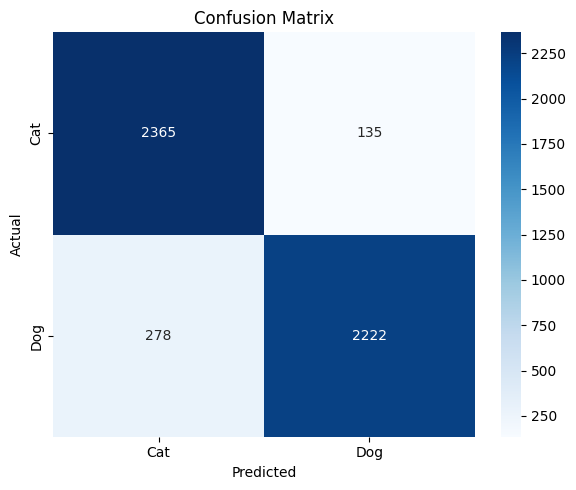

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

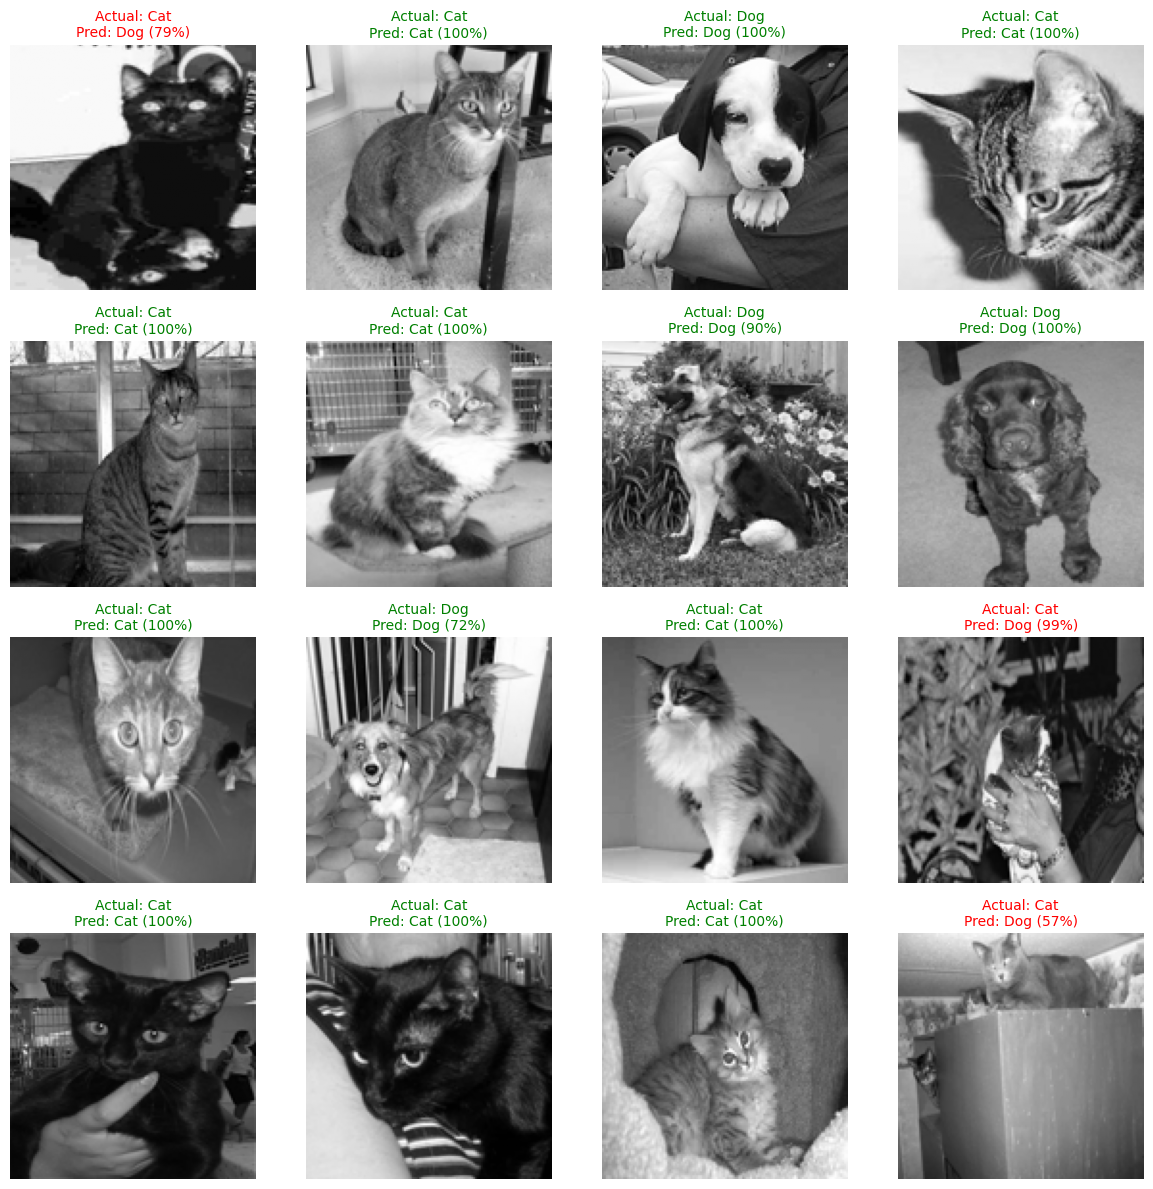

In [43]:
# Display 16 random test predictions

np.random.seed(7)
sample_idx = np.random.choice(len(X_test), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for ax, i in zip(axes, sample_idx):

    actual = label_encoder.inverse_transform([y_test[i]])[0]
    pred = label_encoder.inverse_transform([y_pred[i]])[0]

    confidence = y_pred_probs[i] if y_pred[i] == 1 else 1 - y_pred_probs[i]
    color = "green" if y_test[i] == y_pred[i] else "red"

    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(
        f"Actual: {actual}\nPred: {pred} ({confidence:.0%})",
        color=color,
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Inference on New Data


In [44]:
import gradio as gr
import numpy as np
from PIL import Image

IMG_SIZE = 128

def predict_image(image):

    # Preprocess image
    image = image.convert("L")                 # Convert to grayscale
    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image, dtype=np.float32) / 255.0
    image = image.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    # Predict
    probability = model.predict(image, verbose=0)[0][0]

    predicted_label = int(probability >= 0.5)
    predicted_class = label_encoder.inverse_transform([predicted_label])[0]

    confidence = (
        probability if predicted_label == 1
        else 1 - probability
    )

    return f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}"


demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Textbox(label="Prediction"),
    title="🐱 Cats vs Dogs Classifier 🐶",
    description="Upload an image of a cat or dog."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://75332c06d0003d1613.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
